# Package

In [107]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from eda_utils import plot_reg_and_kde_grid, plot_corr_heatmap

# ----------------------------
# Feature Store
# ----------------------------
from feast import FeatureStore

import itertools
from scipy.stats import pearsonr

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA

# Load

In [108]:
# --------------------------------------------------
# Init Feast
# --------------------------------------------------
REPO_PATH = (
    Path.cwd().parent.parent
    / "2_data_processing"
    / "feature_store"
    / "feast_repo"
    / "feature_repo"
)

store = FeatureStore(repo_path=str(REPO_PATH))

# --------------------------------------------------
# Définir univers temporel
# --------------------------------------------------
dates = pd.date_range(
    start="1960-01-01",
    end="2025-09-01",
    freq="MS",
)

# --------------------------------------------------
# Series IDs (option 1 : explicite, OK pour maintenant)
# --------------------------------------------------
series_ids = [
    "BUSLOANS","CPIAUCSL","DPCERA3M086SBEA","INDPRO",
    "M2SL","OILPRICEX","RPI","SP500","TB3MS","UNRATE","USREC",
]

entity_df = pd.MultiIndex.from_product(
    [series_ids, dates],
    names=["series_id", "date"],
).to_frame(index=False)

# --------------------------------------------------
# Récupération Feast
# --------------------------------------------------
df_stationary = store.get_historical_features(
    entity_df=entity_df,
    features=["stationary_value:value"],
).to_df()

# --------------------------------------------------
# LONG → WIDE
# --------------------------------------------------
df_wide = (
    df_stationary
    .rename(columns={"stationary_value__value": "value"})
    .pivot(index="date", columns="series_id", values="value")
    .sort_index()
)

df = df_wide.copy()

df.head()

Using date as the event timestamp. To specify a column explicitly, please name it event_timestamp.


series_id,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,UNRATE,USREC
date,,,,,,,,,,,
1960-01-01 00:00:00+00:00,0.011578,-0.006156,0.001204,0.091976,0.001323,0.0,0.020977,0.017909,0.30,-0.8,0.0
1960-02-01 00:00:00+00:00,0.011905,-0.003767,0.006009,0.076960,0.002007,0.0,0.014565,-0.025663,-0.19,-1.1,0.0
1960-03-01 00:00:00+00:00,-0.008356,-0.005455,0.021240,0.007959,0.001324,0.0,0.006250,-0.070857,-1.18,-0.2,0.0
1960-04-01 00:00:00+00:00,-0.009098,0.005090,0.033752,-0.025916,0.000634,0.0,0.006489,-0.040442,-1.12,0.0,0.0
1960-05-01 00:00:00+00:00,-0.000359,0.003383,0.009040,-0.018119,0.003977,0.0,0.007747,-0.010090,-0.67,0.0,1.0


In [109]:
df

series_id,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,UNRATE,USREC
date,,,,,,,,,,,
1960-01-01 00:00:00+00:00,0.011578,-0.006156,0.001204,0.091976,0.001323,0.000000,0.020977,0.017909,0.30,-0.8,0.0
1960-02-01 00:00:00+00:00,0.011905,-0.003767,0.006009,0.076960,0.002007,0.000000,0.014565,-0.025663,-0.19,-1.1,0.0
1960-03-01 00:00:00+00:00,-0.008356,-0.005455,0.021240,0.007959,0.001324,0.000000,0.006250,-0.070857,-1.18,-0.2,0.0
1960-04-01 00:00:00+00:00,-0.009098,0.005090,0.033752,-0.025916,0.000634,0.000000,0.006489,-0.040442,-1.12,0.0,0.0
1960-05-01 00:00:00+00:00,-0.000359,0.003383,0.009040,-0.018119,0.003977,0.000000,0.007747,-0.010090,-0.67,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2025-05-01 00:00:00+00:00,0.044487,-0.007941,0.007758,0.000360,0.004820,-0.162581,0.008190,-0.038448,0.03,0.2,0.0
2025-06-01 00:00:00+00:00,0.035593,-0.000435,0.002578,0.005179,0.004174,0.026151,0.001403,0.059087,0.03,0.0,0.0
2025-07-01 00:00:00+00:00,-0.001303,0.001775,0.005014,0.001050,-0.001062,0.249194,-0.003535,0.159259,0.04,0.0,0.0


In [110]:
nan_dates = df.index[df.isna().any(axis=1)]

print(nan_dates[:20])   # premières dates
print("Nombre total :", len(nan_dates))

DatetimeIndex(['2025-09-01 00:00:00+00:00'], dtype='datetime64[ns, UTC]', name='date', freq=None)
Nombre total : 1


In [111]:
df = df.loc[: "2025-08-31"].copy()

In [112]:
df_train = df[df.index.year < 1990]
df_test = df.loc[df.index.difference(df_train.index)]

In [113]:
# Variables explicatives
X_train = df_train.drop("UNRATE", axis=1)
X_test = df_test.drop("UNRATE", axis=1)

# 1-Etude de la coorélation bivariée entre variables

d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


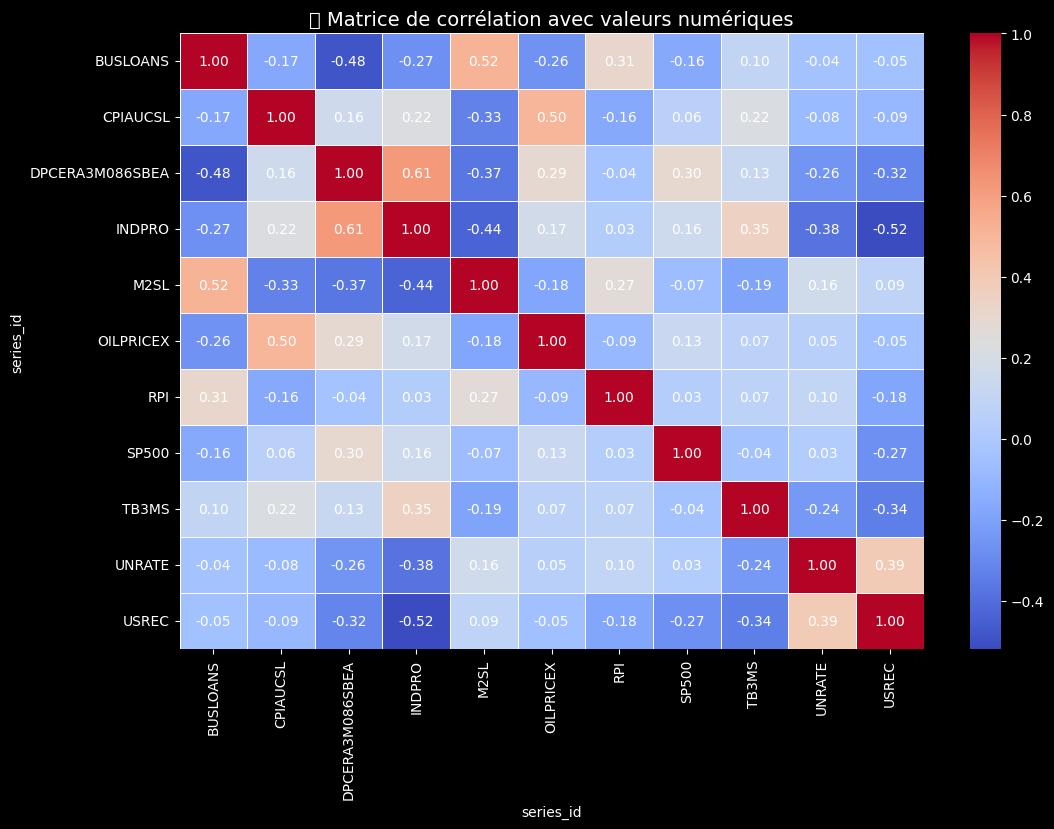

In [114]:
# Style sombre (fond noir global)
plt.style.use("dark_background")

plt.figure(figsize=(12, 8))

# Heatmap
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.7,
    cbar=True,
    annot_kws={"color": "white"}  # chiffres lisibles sur fond sombre
)

# Titre
plt.title("📌 Matrice de corrélation avec valeurs numériques", fontsize=14, color="white")

# Axe en blanc
plt.xticks(color="white")
plt.yticks(color="white")

plt.show()

# Test de significativité

In [115]:
# Test de significativité de coorélation
results = []
for var1, var2 in itertools.combinations(df.columns, 2):
    r, p = pearsonr(df_test[var1], df_test[var2])
    results.append({
        "Variable_1": var1,
        "Variable_2": var2,
        "Correlation": r,
        "p_value": p,
        "Significatif_5pct": "Oui" if p < 0.05 else "Non"
    })

df_corr_sig = pd.DataFrame(results).sort_values(by="Correlation", ascending=False).reset_index(drop=True)

In [116]:
df_corr_sig.head()

,Variable_1,Variable_2,Correlation,p_value,Significatif_5pct
0,DPCERA3M086SBEA,INDPRO,0.749029,3.526202e-78,Oui
1,BUSLOANS,M2SL,0.676013,1.859328e-58,Oui
2,CPIAUCSL,OILPRICEX,0.600218,3.058270e-43,Oui
3,DPCERA3M086SBEA,OILPRICEX,0.395856,1.652240e-17,Oui
4,BUSLOANS,RPI,0.357864,2.236442e-14,Oui


In [117]:
df_corr_sig["Significatif_5pct"].value_counts()

Significatif_5pct
Oui    45
Non    10
Name: count, dtype: int64

# Commentaire
Le test de significativité de coorélation entre variable explicative a fait montré que 31 paires de variables sont coorélées linéairement entre eux. Pour plus de précision, nous allons effectuer le VIF.

## VIF (Variance Inflation Factor)

In [118]:
df

series_id,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,UNRATE,USREC
date,,,,,,,,,,,
1960-01-01 00:00:00+00:00,0.011578,-0.006156,0.001204,0.091976,0.001323,0.000000,0.020977,0.017909,0.30,-0.8,0.0
1960-02-01 00:00:00+00:00,0.011905,-0.003767,0.006009,0.076960,0.002007,0.000000,0.014565,-0.025663,-0.19,-1.1,0.0
1960-03-01 00:00:00+00:00,-0.008356,-0.005455,0.021240,0.007959,0.001324,0.000000,0.006250,-0.070857,-1.18,-0.2,0.0
1960-04-01 00:00:00+00:00,-0.009098,0.005090,0.033752,-0.025916,0.000634,0.000000,0.006489,-0.040442,-1.12,0.0,0.0
1960-05-01 00:00:00+00:00,-0.000359,0.003383,0.009040,-0.018119,0.003977,0.000000,0.007747,-0.010090,-0.67,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01 00:00:00+00:00,0.046085,-0.007236,0.007959,0.011685,0.004244,-0.226416,0.015108,-0.107606,0.00,0.3,0.0
2025-05-01 00:00:00+00:00,0.044487,-0.007941,0.007758,0.000360,0.004820,-0.162581,0.008190,-0.038448,0.03,0.2,0.0
2025-06-01 00:00:00+00:00,0.035593,-0.000435,0.002578,0.005179,0.004174,0.026151,0.001403,0.059087,0.03,0.0,0.0


In [119]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================================
# Segments temporels
# ============================================================
segments = [
    ("1990-01-01", "1999-12-31", "1990-1999"),
    ("2000-01-01", "2008-12-31", "2000-2008"),
    ("2008-01-01", "2019-12-31", "2008-2019"),
    ("2020-01-01", None,         "2020-fin"),
]

# ============================================================
# Fonction VIF
# ============================================================
def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    X_clean = X.dropna().copy()

    if X_clean.shape[1] < 2:
        raise ValueError("Need at least 2 features for VIF.")

    vif_values = [
        variance_inflation_factor(X_clean.values, i)
        for i in range(X_clean.shape[1])
    ]

    return pd.DataFrame({
        "feature": X_clean.columns,
        "VIF": vif_values
    })

# ============================================================
# VIF par segments
# ============================================================
vif_results = []

for start, end, label in segments:

    df_seg = df.loc[start:] if end is None else df.loc[start:end]
    X_seg = df_seg.copy()

    vif_seg = compute_vif(X_seg)
    vif_seg["period"] = label

    vif_results.append(vif_seg)

# ============================================================
# VIF global ALL après 1990
# ============================================================
df_all_post1990 = df.loc["1990-01-01":].copy()

vif_all = compute_vif(df_all_post1990)
vif_all["period"] = "ALL_1990-fin"

vif_results.append(vif_all)

# ============================================================
# Tableau final
# ============================================================
df_vif_all = pd.concat(vif_results, ignore_index=True)

vif_pivot = df_vif_all.pivot(
    index="feature",
    columns="period",
    values="VIF"
)

# ordre colonnes
col_order = [
    "ALL_1990-fin",
    "1990-1999",
    "2000-2008",
    "2008-2019",
    "2020-fin"
]
vif_pivot = vif_pivot[col_order]

# ⭐ TRI PAR ALL_1990-fin
vif_pivot = vif_pivot.sort_values(
    by="ALL_1990-fin",
    ascending=False
)

print(vif_pivot.round(2))

period           ALL_1990-fin  1990-1999  2000-2008  2008-2019  2020-fin
feature                                                                 
DPCERA3M086SBEA          3.49       3.83       1.97       2.04      9.22
INDPRO                   3.47       3.33       2.69       2.77     13.35
BUSLOANS                 3.00       1.16       1.15       1.58     10.60
M2SL                     2.38       1.22       1.47       1.89      8.51
OILPRICEX                1.80       1.78       1.95       3.11      4.28
CPIAUCSL                 1.72       1.59       1.89       3.17      3.43
USREC                    1.66       1.24       2.64       3.71      1.79
UNRATE                   1.61       2.38       2.37       1.92      2.65
TB3MS                    1.45       2.45       2.17       2.27      1.93
RPI                      1.44       3.01       1.66       1.68      1.80
SP500                    1.35       1.98       2.17       2.28      2.15


Le VIF global après 1990 reste modéré. Cela montre qu’il n’y a pas de forte multicolinéarité sur l’ensemble de la période. En revanche, après 2020, plusieurs variables ont un VIF beaucoup plus élevé. Les indicateurs macroéconomiques évoluent donc plus ensemble dans cette période récente, ce qui peut rendre le modèle moins stable et les prévisions plus incertaines.

Nous allons effectuer une analye multivariée dans la période d'après 2019 uniquement pour révéler la nature des relations

# ACP

In [120]:
df_after_2019 = df[df.index.year > 2019]
df_after_2019 = df_after_2019[df_after_2019.index < "2020-08-31"]
df_after_2019.head()

series_id,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,UNRATE,USREC
date,,,,,,,,,,,
2020-01-01 00:00:00+00:00,-0.017611,0.002364,0.011554,-0.003895,-0.004597,0.124819,0.008522,0.096150,-0.13,-0.4,0.0
2020-02-01 00:00:00+00:00,-0.009860,-0.001870,0.002722,-0.005545,-0.010275,-0.160517,0.009396,0.054041,-0.02,-0.3,0.0
2020-03-01 00:00:00+00:00,0.089473,-0.010687,-0.066898,-0.043124,0.020373,-0.768000,0.000208,-0.180398,-1.25,0.6,1.0
2020-04-01 00:00:00+00:00,0.222848,-0.019655,-0.187417,-0.177971,0.081796,-1.309636,0.104616,-0.171347,-1.38,11.1,1.0
2020-05-01 00:00:00+00:00,0.263542,-0.018692,-0.104006,-0.164925,0.131109,-0.449946,0.057029,-0.115569,-1.39,9.6,0.0


In [121]:
X_after_2019 = df_after_2019.drop("UNRATE", axis = 1)

In [124]:
# --- 2) Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_after_2019)

In [125]:
# On installe l'ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [126]:
# Pourcentage de variance expliquée par axe
print("Variance expliquée (%) :", pca.explained_variance_ratio_ * 100)

# Valeurs propres
print("Valeurs propres :", pca.explained_variance_)

Variance expliquée (%) : [7.86386087e+01 1.29730555e+01 3.73172877e+00 3.17607216e+00
 1.40332281e+00 6.95598333e-02 7.65224480e-03 1.67825007e-32]
Valeurs propres : [8.98726956e+00 1.48263491e+00 4.26483288e-01 3.62979676e-01
 1.60379749e-01 7.94969524e-03 8.74542262e-04 1.91800008e-33]


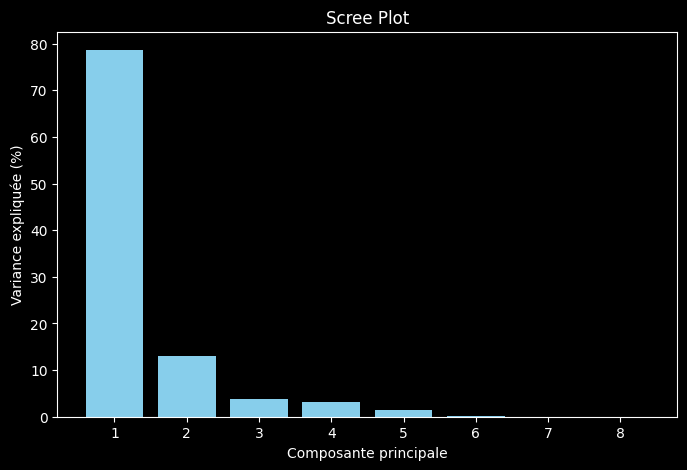

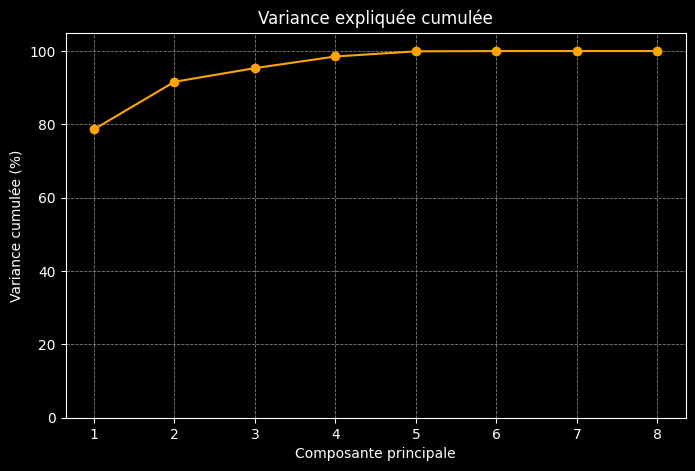

In [127]:
# Image des valeurs propres
evr = pca.explained_variance_ratio_ * 100  # en %

# --- Thème DARK ---
plt.style.use("dark_background")

# --- Scree Plot ---
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(evr)+1), evr, color="skyblue")
plt.xlabel("Composante principale", color="white")
plt.ylabel("Variance expliquée (%)", color="white")
plt.title("Scree Plot", color="white")
plt.xticks(range(1, len(evr)+1), color="white")
plt.yticks(color="white")
plt.show()

# --- Variance cumulée ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(evr)+1), np.cumsum(evr), marker="o", color="orange")
plt.xlabel("Composante principale", color="white")
plt.ylabel("Variance cumulée (%)", color="white")
plt.title("Variance expliquée cumulée", color="white")
plt.xticks(range(1, len(evr)+1), color="white")
plt.yticks(color="white")
plt.ylim(0, 105)
plt.grid(color="gray", linestyle="--", linewidth=0.6)  # grille lisible sur fond noir
plt.show()

## ACP sur les 02 premiers axes

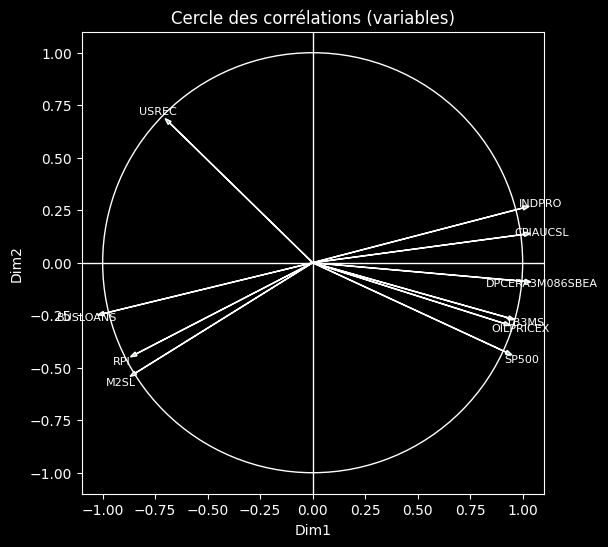

In [128]:
# Cercle des corrélations (variables)
# Pour données standardisées, corr(var, axe) = composantes * sqrt(valeurs_propres)
features = getattr(X, "columns", [f"V{i+1}" for i in range(pca.components_.shape[1])])
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)   # (p x k)
corr = loadings[:, :2]

plt.figure(figsize=(6,6))
circle = plt.Circle((0, 0), 1, fill=False, linewidth=1)
plt.gca().add_artist(circle)
for i in range(corr.shape[0]):
    plt.arrow(0, 0, corr[i, 0], corr[i, 1], head_width=0.02, length_includes_head=True)
    plt.text(corr[i, 0]*1.05, corr[i, 1]*1.05, str(features[i]), ha='center', va='center', fontsize=8)
plt.axhline(0, linewidth=1); plt.axvline(0, linewidth=1)
plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("Dim1"); plt.ylabel("Dim2")
plt.title("Cercle des corrélations (variables)")
plt.show()

# On va ajouter UNRATE comme variable supplémentaire dans l'ACP

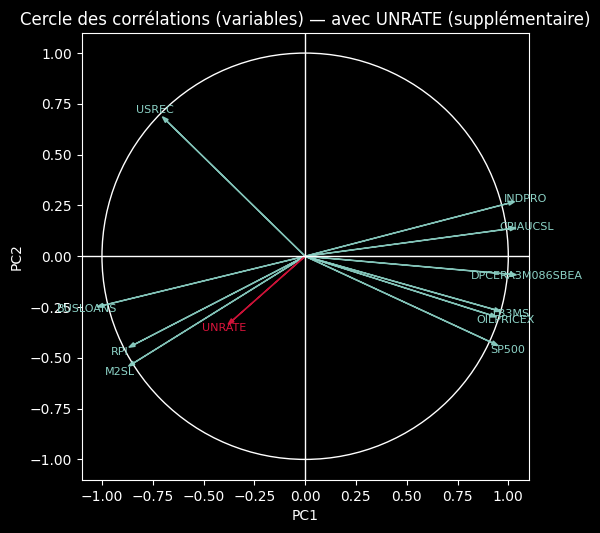

In [129]:
# --- (on suppose que X = df_stationary_train sans 'UNRATE', déjà nettoyé comme pour ta PCA) ---
# Si tu n'as pas encore les 'scores' (coordonnées individus), on les (re)calcule :
from sklearn.preprocessing import StandardScaler
try:
    X_scaled  # existe déjà ?
except NameError:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

scores = pca.transform(X_scaled)  # (n_obs x n_PC)

# --- 1) Corrélations variables-axes (déjà dans ton code) ---
# loadings = pca.components_.T * np.sqrt(pca.explained_variance_)   # (p x k)
# corr = loadings[:, :2]  # coordonnées des variables sur (PC1, PC2)

# --- 2) Ajouter UNRATE comme variable SUPPLÉMENTAIRE ---
# On aligne UNRATE sur les mêmes lignes que X (et on retire les NaN éventuels côté UNRATE)
y_all = df_after_2019.loc[X_after_2019.index, "UNRATE"].astype(float)
mask  = y_all.notna()
y     = y_all[mask].values
scores_aligned = scores[mask.values, :]  # mêmes lignes

# Corrélation de UNRATE avec chaque axe (ici PC1, PC2)
r_unrate_pc1 = np.corrcoef(y, scores_aligned[:, 0])[0, 1]
r_unrate_pc2 = np.corrcoef(y, scores_aligned[:, 1])[0, 1]
unrate_coords = np.array([r_unrate_pc1, r_unrate_pc2])

# On étend les tableaux pour le tracé
features_ext = list(features) + ["UNRATE"]
corr_ext = np.vstack([corr, unrate_coords])

# --- 3) Tracé du cercle + UNRATE en couleur distincte ---
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
ax = plt.gca()
ax.add_artist(plt.Circle((0,0), 1, fill=False, linewidth=1))

for i in range(corr_ext.shape[0]):
    is_unrate = (features_ext[i] == "UNRATE")
    color = "crimson" if is_unrate else "C0"
    ax.arrow(0, 0, corr_ext[i, 0], corr_ext[i, 1],
             head_width=0.02, length_includes_head=True, color=color, alpha=0.9)
    ax.text(corr_ext[i, 0]*1.05, corr_ext[i, 1]*1.05, str(features_ext[i]),
            ha='center', va='center', fontsize=8, color=color)

ax.axhline(0, linewidth=1); ax.axvline(0, linewidth=1)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Cercle des corrélations (variables) — avec UNRATE (supplémentaire)")
plt.tight_layout()
plt.show()

### Synthèse

L’ACP montre qu’après 2019, le taux de chômage américain (UNRATE) évolue en opposition aux indicateurs d’activité économique, ce qui confirme son caractère contracyclique. La première composante reflète le cycle réel de l’économie, avec la production industrielle, l’utilisation des capacités et les marchés financiers.

La seconde composante traduit davantage les épisodes de stress macroéconomique ou de récession. La structure observée suggère un changement de régime après le choc COVID. La dynamique du chômage dépend surtout de la reprise réelle de l’économie plutôt que des variables monétaires, ce qui souligne l’importance des facteurs macro réels dans l’analyse et la prévision.

Le chômage n’est plus lié au revenu des ménages. Cette situation n’est pas normale dans un fonctionnement économique classique. Elle s’explique par l’effet des politiques de relance budgétaire mises en place pendant le COVID-19 — notamment le CARES Act (2020) et l’American Rescue Plan (2021) — qui ont fortement soutenu les revenus des ménages grâce à des transferts publics directs (chèques stimulus, allocations chômage renforcées, crédits d’impôt).

Dans la majorité des périodes, on anticipe donc 